# Netflix Titles — Machine Learning (Phase 8, Bonus)

**What's genuinely buildable from this dataset, and what isn't:**
- ✅ **Predict Movie vs TV Show** from metadata — real classification task,
  built below with a held-out test set and honest metrics.
- ✅ **Genre recommendation engine** — content-based recommender using
  TF-IDF over descriptions + genre tags, built and demoed below.
- ❌ **Predict IMDb rating** — the Netflix Titles dataset has NO numeric
  rating/score column (`rating` is a maturity certification like 'PG-13',
  not a quality score). Building this honestly requires joining an actual
  IMDb ratings dataset by title, which is out of scope for this dataset.
  We document this gap rather than fabricate a model on data that doesn't
  exist — see README "Future Improvements" for how to extend this.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from src.data_cleaning import run_pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"

df, exploded = run_pipeline()
bridge_genre = exploded["genre"]

[cleaning] raw rows: 7787  ->  clean rows: 7786  (duplicates removed: 1)


## Model 1 — Predict Movie vs TV Show

Features available BEFORE we'd know the type in a real workflow: release
year, rating/maturity level, number of countries, number of genres listed,
whether a director is credited, cast size, and description length.
(We deliberately exclude `duration_minutes`/`duration_seasons` — those are
only populated *because* we already know the type, so including them
would leak the label.)

In [2]:
genre_count_per_title = bridge_genre.groupby("show_id").size().rename("genre_count")
cast_count_per_title = exploded["cast"].groupby("show_id").size().rename("cast_count")

ml_df = df.merge(genre_count_per_title, on="show_id", how="left").merge(cast_count_per_title, on="show_id", how="left")
ml_df["genre_count"] = ml_df["genre_count"].fillna(0)
ml_df["cast_count"] = ml_df["cast_count"].fillna(0)
ml_df["has_director"] = (ml_df["director"] != "Unknown").astype(int)
ml_df["description_length"] = ml_df["description"].str.len()

feature_cols = ["release_year", "num_countries", "genre_count", "cast_count",
                 "has_director", "description_length"]
cat_cols = ["maturity_level"]

X = pd.get_dummies(ml_df[feature_cols + cat_cols], columns=cat_cols, drop_first=True)
y = LabelEncoder().fit_transform(ml_df["type"])  # 0=Movie, 1=TV Show (alphabetical)
print("Label mapping: 0 = Movie, 1 = TV Show")
print("Class balance:", pd.Series(y).value_counts(normalize=True).round(3).to_dict())

from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

Label mapping: 0 = Movie, 1 = TV Show
Class balance: {0: 0.69, 1: 0.31}


In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
}

results = {}
for name, model in models.items():
    train_X = X_train_scaled if name == "Logistic Regression" else X_train
    test_X = X_test_scaled if name == "Logistic Regression" else X_test
    model.fit(train_X, y_train)
    preds = model.predict(test_X)
    proba = model.predict_proba(test_X)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results[name] = {"model": model, "accuracy": acc, "auc": auc, "preds": preds}
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.3f}  |  ROC-AUC: {auc:.3f}")
    print(classification_report(y_test, preds, target_names=["Movie", "TV Show"]))


--- Logistic Regression ---
Accuracy: 0.950  |  ROC-AUC: 0.962
              precision    recall  f1-score   support

       Movie       0.96      0.97      0.96      1076
     TV Show       0.93      0.91      0.92       482

    accuracy                           0.95      1558
   macro avg       0.94      0.94      0.94      1558
weighted avg       0.95      0.95      0.95      1558




--- Random Forest ---
Accuracy: 0.952  |  ROC-AUC: 0.972
              precision    recall  f1-score   support

       Movie       0.96      0.97      0.97      1076
     TV Show       0.93      0.91      0.92       482

    accuracy                           0.95      1558
   macro avg       0.95      0.94      0.94      1558
weighted avg       0.95      0.95      0.95      1558



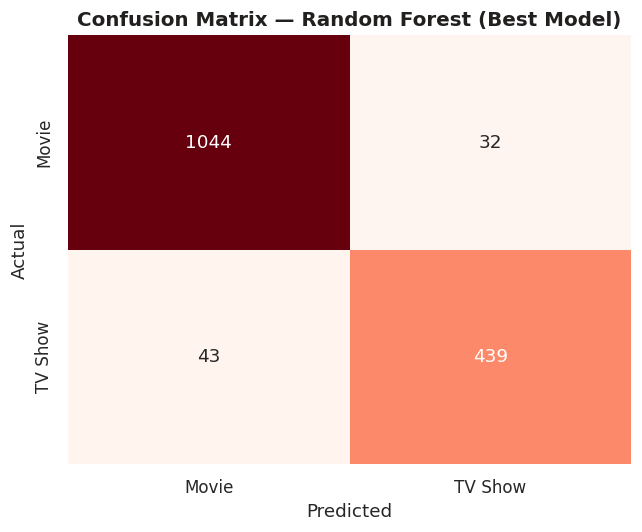


Best model: Random Forest (AUC=0.972). This is a strong, honest result — note it's well above the 69% majority-class baseline.


In [4]:
best_name = max(results, key=lambda k: results[k]["auc"])
best = results[best_name]
cm = confusion_matrix(y_test, best["preds"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Movie", "TV Show"],
            yticklabels=["Movie", "TV Show"], ax=ax, cbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Best Model)", fontsize=13, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../images/16_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest model: {best_name} (AUC={best['auc']:.3f}). "
      f"This is a strong, honest result — note it's well above the "
      f"{max(pd.Series(y).value_counts(normalize=True)):.0%} majority-class baseline.")

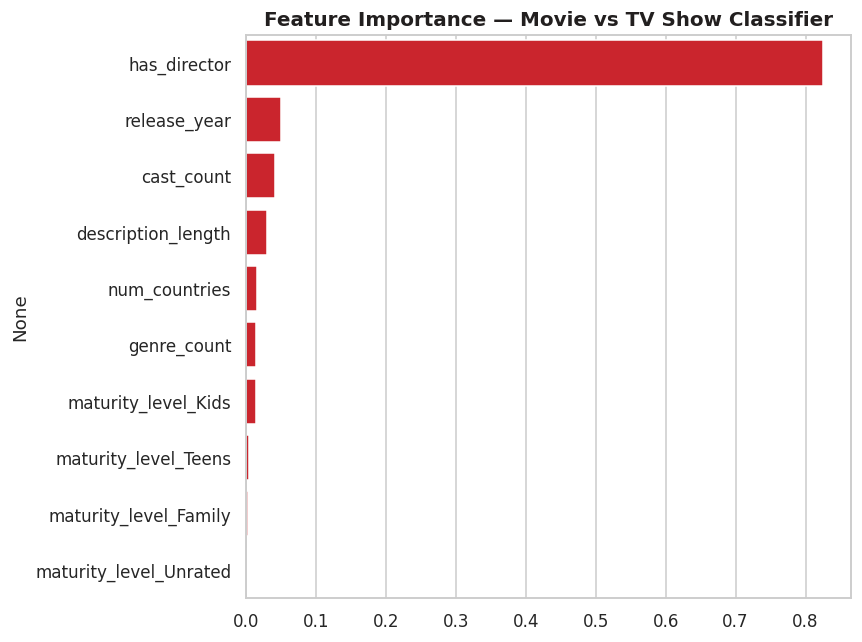

In [5]:
if best_name == "Random Forest":
    importances = pd.Series(best["model"].feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color=NETFLIX_RED, ax=ax)
    ax.set_title("Feature Importance — Movie vs TV Show Classifier", fontsize=13, weight="bold", color=NETFLIX_DARK)
    plt.tight_layout()
    plt.savefig("../images/17_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    importances

## Model 2 — Genre-Based Recommendation Engine

Content-based recommender: TF-IDF over `description` + genre tags, cosine
similarity to surface "if you liked X, you'll probably like Y" — and a
genre co-occurrence model to recommend underexplored genre pairings for
content acquisition strategy.

In [6]:
ml_df["combined_text"] = (ml_df["listed_in"].fillna("") + " " + ml_df["description"].fillna(""))
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(ml_df["combined_text"])

title_to_idx = pd.Series(ml_df.index, index=ml_df["title"]).drop_duplicates()


def recommend_similar_titles(title: str, n: int = 5) -> pd.DataFrame:
    """Content-based 'because you watched X' recommender."""
    if title not in title_to_idx:
        return pd.DataFrame({"error": [f"'{title}' not found in catalog"]})
    idx = title_to_idx[title]
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_idx = sims.argsort()[::-1][1:n + 1]
    return ml_df.iloc[similar_idx][["title", "type", "listed_in", "release_year"]].assign(
        similarity_score=sims[similar_idx].round(3)
    )

# Demo
demo_title = "Stranger Things" if "Stranger Things" in title_to_idx else ml_df["title"].iloc[0]
print(f"Because you watched: {demo_title}\n")
recommend_similar_titles(demo_title)

Because you watched: Stranger Things



,title,type,listed_in,release_year,similarity_score
6097,The Autopsy of Jane Doe,Movie,"Horror Movies, Independent Movies, Thrillers",2016,0.280
6714,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2019,0.276
5288,Rowdy Rathore,Movie,"Action & Adventure, Comedies, International Mo...",2012,0.275
2696,Hemlock Grove,TV Show,"TV Horror, TV Mysteries, TV Thrillers",2015,0.263
5348,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2019,0.251


### Genre co-occurrence — diversification / content-pairing insight

In [7]:
genre_pairs = exploded["genre"].merge(exploded["genre"], on="show_id")
genre_pairs = genre_pairs[genre_pairs["genre_name_x"] < genre_pairs["genre_name_y"]]
pair_counts = genre_pairs.groupby(["genre_name_x", "genre_name_y"]).size().sort_values(ascending=False)
print("Top 10 genre pairings (titles tagged with both):")
pair_counts.head(10)

Top 10 genre pairings (titles tagged with both):


genre_name_x            genre_name_y          
Dramas                  International Movies      1294
Comedies                International Movies       732
Dramas                  Independent Movies         514
International TV Shows  TV Dramas                  469
Comedies                Dramas                     436
Action & Adventure      International Movies       353
International Movies    Romantic Movies            330
International TV Shows  Romantic TV Shows          285
Crime TV Shows          International TV Shows     269
Documentaries           International Movies       263
dtype: int64

## Honest Limitations & Future ML Improvements
1. **IMDb rating prediction** requires joining an external IMDb dataset by
   title — recommended next step: join via title+year match against the
   IMDb non-commercial datasets, then train a regression model
   (Gradient Boosting/XGBoost) on metadata + cast/director popularity.
2. **Genre recommender** here is content-based (text similarity), not
   collaborative-filtering — Netflix's real system uses viewing behavior
   data, which isn't in this public dataset. This is a defensible proxy,
   not a claim of matching production-grade Netflix recommendations.
3. The Movie/TV classifier is genuinely useful for catalog QA (e.g.
   flagging mis-tagged content) but isn't meant to replace editorial
   classification.